
# 04.3 – Hazards and Max Run Length

The hazard function encodes the prior probability of a changepoint before we
see the current datum. ``max_run_length`` limits how much history Fast-BOCPD
tracks for numerical stability and performance. This notebook explains the
constant hazard, how ``lambda`` tunes reaction speed, and how to choose an
appropriate run-length cap.



## 0. Environment setup


In [1]:

import sys
from pathlib import Path

CWD = Path.cwd()
REPO_ROOT = CWD if (CWD / "fast_bocpd").exists() else CWD.parent
EXAMPLES_DIR = REPO_ROOT / "examples"

sys.path.append(str(REPO_ROOT))
sys.path.append(str(EXAMPLES_DIR))


## 1. Imports and helpers


In [2]:

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

from fast_bocpd import BOCPD, ConstantHazard, GaussianNIG

from _helpers import generate_piecewise_gaussian, plot_series_with_cp, seed_everything



### Streaming helper


In [3]:

seed_everything(42)

def run_bocpd_series(values, hazard, obs_model=None, max_run_length=400):
    """Stream data through BOCPD and collect diagnostics."""
    values = np.asarray(values)
    if obs_model is None:
        obs_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=0.2, beta0=0.2)
    bocpd = BOCPD(obs_model=obs_model, hazard=hazard, max_run_length=max_run_length)
    cp_probs = []
    map_r = []
    for value in values:
        _, cp_prob = bocpd.update(float(value))
        cp_probs.append(cp_prob)
        map_r.append(bocpd.get_map_run_length())
    return pd.DataFrame(
        {
            "t": np.arange(len(values)),
            "value": values,
            "cp_prob": cp_probs,
            "map_r": map_r,
        }
    )



## 2. Hazard intuition

The hazard $H(r)$ gives the probability that a new segment begins when the
current run length is $r$. It plays the same role as a discrete-time failure
rate in survival analysis. Observation models only affect the likelihood; the
hazard is where you express prior beliefs about how often changepoints occur.

We currently ship a **constant hazard**

$$H(r) = \frac{1}{\lambda}$$

which implies a geometric distribution over segment lengths with mean
$\mathbb{E}[R] = \lambda$. Smaller ``lambda`` yields aggressive,
frequent changepoints; larger ``lambda`` assumes long stable regimes.


### Constant hazard values over run length


In [4]:

lambda_ = 150
run_lengths = np.arange(0, 600)
hazard_values = np.full_like(run_lengths, fill_value=1.0 / lambda_, dtype=float)
survival = (1 - 1.0 / lambda_) ** run_lengths

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=(
        "Hazard H(r) for ConstantHazard(lambda=150)",
        "Survival probability P(run length ≥ r)",
    ),
)
fig.add_trace(go.Scatter(x=run_lengths, y=hazard_values, mode="lines", name="H(r)"), row=1, col=1)
fig.add_trace(go.Scatter(x=run_lengths, y=survival, mode="lines", name="Survival"), row=2, col=1)
fig.update_layout(
    height=520,
    template="plotly_white",
    xaxis_title="Run length r",
    yaxis_title="Hazard",
    xaxis2_title="Run length r",
    yaxis2_title="Survival",
)
fig



## 3. Tuning ``lambda`` (expected segment length)

We'll reuse a Gaussian signal with two changepoints and vary ``lambda``.
Pick ``lambda`` close to your expected distance between changepoints:

- ``lambda`` too small → the prior expects frequent resets and you risk false alarms.
- ``lambda`` too large → changepoint probability builds slowly and you may miss short regimes.


In [5]:

df, cps = generate_piecewise_gaussian(
    lengths=[150, 200, 150],
    means=[0.0, 1.0, -0.2],
    sigma=0.25,
    seed=21,
)
obs_model = GaussianNIG(mu0=0.0, kappa0=0.8, alpha0=0.3, beta0=0.3)
lambdas = [60, 180, 400]
lambda_results = {}
for lam in lambdas:
    hazard = ConstantHazard(lambda_=lam)
    lambda_results[lam] = run_bocpd_series(
        df["value"],
        hazard,
        obs_model=obs_model,
        max_run_length=600,
    )


### Compare responses


In [6]:

for lam in lambdas:
    result = lambda_results[lam]
    fig = plot_series_with_cp(
        result,
        value_col="value",
        cp_prob_col="cp_prob",
        changepoints=cps,
        title=f"lambda = {lam} (expected segment ≈ {lam} samples)",
    )
    fig.update_layout(height=360)
    display(fig)



* ``lambda = 60`` reacts quickly but tends to raise ``cp_prob`` even inside a
  stable regime.
* ``lambda = 180`` matches the true mean segment length and balances speed with
  stability.
* ``lambda = 400`` assumes long regimes, so we only get a spike when the evidence
  is overwhelming.



## 4. Choosing ``max_run_length``

``max_run_length`` truncates the posterior and directly controls CPU/memory.
The update cost is `O(max_run_length)`, so increasing it improves
accuracy but slows processing. Keep it higher than your 99th percentile segment
length; too small and you'll see spurious changepoints in long stable periods.

Rules of thumb:
1. Start near ``4 × lambda``.
2. Increase it when the signal has long plateaus.
3. Decrease it only if profiling shows the C backend dominating runtime.


In [7]:

df_long, cps_long = generate_piecewise_gaussian(
    lengths=[320, 90, 120],
    means=[0.0, 1.1, -0.2],
    sigma=0.2,
    seed=12,
)
hazard_long = ConstantHazard(lambda_=200)
small_run = run_bocpd_series(
    df_long["value"],
    hazard_long,
    obs_model=obs_model,
    max_run_length=80,
)
large_run = run_bocpd_series(
    df_long["value"],
    hazard_long,
    obs_model=obs_model,
    max_run_length=500,
)


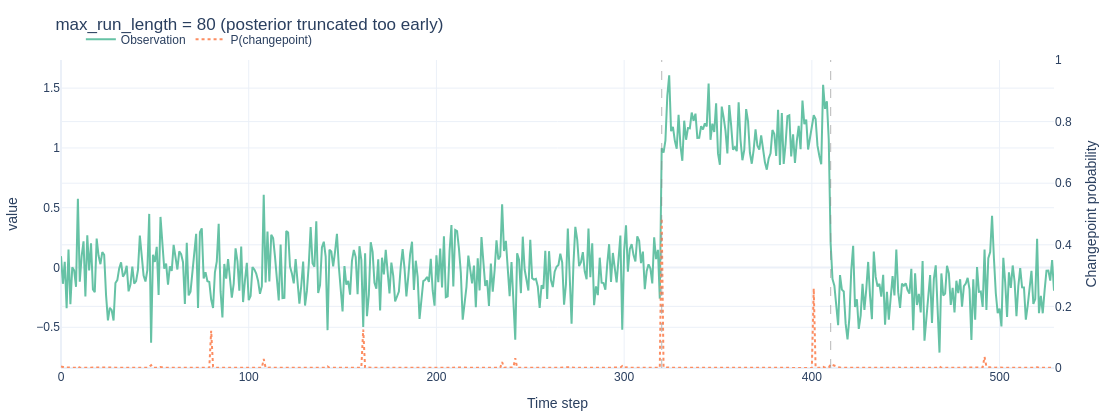

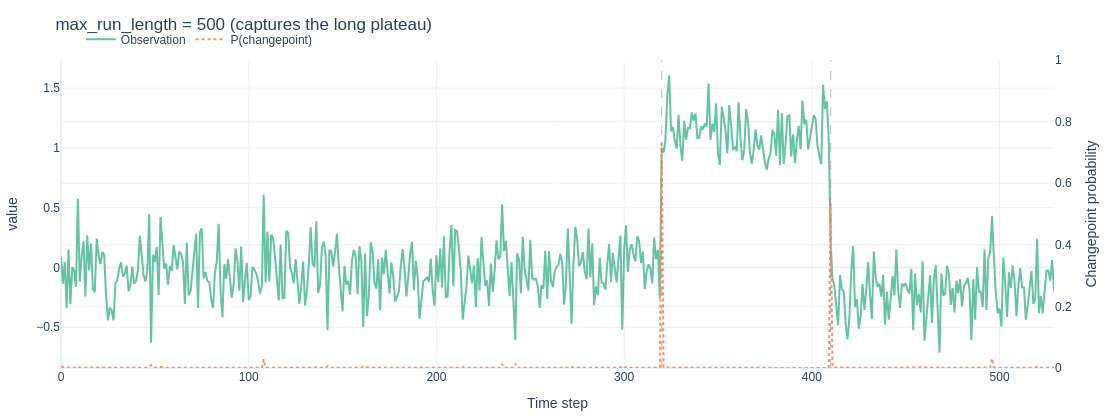

In [8]:

fig_small = plot_series_with_cp(
    small_run,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=cps_long,
    title="max_run_length = 80 (posterior truncated too early)",
)
fig_large = plot_series_with_cp(
    large_run,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=cps_long,
    title="max_run_length = 500 (captures the long plateau)",
)
display(fig_small)
display(fig_large)



With ``max_run_length = 80`` the detector is forced to forget that the first
segment has been stable for hundreds of samples, so the baseline ``cp_prob``
creeps upward. Increasing it to 500 keeps the posterior mass concentrated on
long run lengths until the true changepoint near t ≈ 320.



## 5. Practical checklist

1. Use domain knowledge or exploratory batching to estimate the average segment
   length and set ``lambda`` accordingly.
2. Initialize ``max_run_length`` between ``3×`` and ``6×`` ``lambda``; bump it if
   you still see drift during stable periods.
3. When ``lambda`` is small, raise alert thresholds (e.g. ``min_cp_prob`` in
   ``OnlineChangeDetector``) to avoid false positives.
4. Profile end-to-end throughput before shrinking ``max_run_length``—our C core
   handles values in the several-thousand range comfortably on modern hardware.
